In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.colors import CMAP
from utils.problem_setup import TestProblemsSetup

#from algorithms.dynamical_low_rank_solver import DynamicalLowRankSolver
from algorithms.cg_solvers import DynamicalLowRankCG, DynamicalLowRankApproximation
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

PROBLEMS = TestProblemsSetup(n=64).get_test_problems()
PARAMS = TestProblemsSetup(n=64).problem_params['I']
SEED = 15

In [46]:
f_list = []
max_ranks = [1, 2]

pid = 'I'
pb = PROBLEMS[pid]

rsvd = MatrixFreeRSVD(pb['V_h'])
rsvd.solve(k=50)
w = rsvd.weights()

def as_func(x, V_h):
    f = Function(V_h)
    f.vector()[:] = x
    return f

def plot_multiple_f(f_list, params=None, names=None, fig_name=None, shrink=0.3):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches

    width, height = PARAMS['width'], PARAMS['height']
    x0s, y0s = PARAMS['x0'], PARAMS['y0']

    fig, axes = plt.subplots(1, len(f_list), figsize=(9, 6.06), constrained_layout=True)

    if names is None:
        names = ['' for _ in axes.flat]

    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        #vmin = np.min(func.vector().get_local())

        p = plot(func, title=name, cmap=CMAP)
        fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    save_plot(fig_name=fig_name)
    plt.show()

In [122]:
lam = 1e-4
params_adam  = {'method': 'adam',  'max_rank': 1, 'rtol': 1e-4, 'verbose': True, 'max_iter': 5_000, 'seed': SEED}
params_fixed = {'method': 'fixed', 'max_rank': 1, 'rtol': 1e-4, 'verbose': True, 'max_iter': 10_000, 'alpha': 2000, 'seed': SEED}
params_sd    = {'method': 'sd', 'max_rank': 1, 'rtol': 1e-4, 'verbose': True, 'max_iter': 5_000, 'seed': SEED}

solver_dlra = DynamicalLowRankApproximation(rsvd)
solver_dlra.x_true = pb['x']

x_adam = solver_dlra.solve(pb['y'], w, lam, **params_adam)
e_adam = solver_dlra.error.copy()
r_adam = solver_dlra.residual.copy()

x_fixed = solver_dlra.solve(pb['y'], w, lam, **params_fixed)
e_fixed = solver_dlra.error.copy()
r_fixed = solver_dlra.residual.copy()

x_sd = solver_dlra.solve(pb['y'], w, lam, **params_sd)
e_sd = solver_dlra.error.copy()
r_sd = solver_dlra.residual.copy()

f_list = [as_func(x, pb['V_h']) for x in [x_adam, x_fixed, x_sd]]

[##############################] 5000/5000
[##############################] 10000/10000
[##############################] 5000/5000


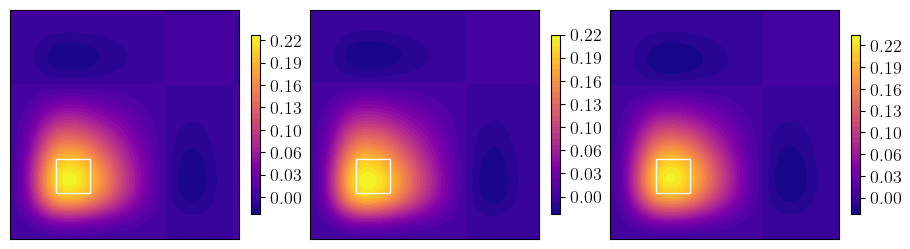

In [123]:
plot_multiple_f(f_list)

In [124]:
params_cg = {'max_rank': 1, 'rtol': 1e-50, 'max_iter': 1_000, 'seed': SEED, 'restart_every': None}
params_cg_restart = {'max_rank': 1, 'rtol': 1e-6, 'max_iter': 1_000, 'seed': SEED, 'restart_every': 10}

# DLR-CG solution
solver_cg = DynamicalLowRankCG(rsvd)
solver_cg.x_true = pb['x']

x_cg = solver_cg.solve(pb['y'], w, lam, **params_cg)
e_cg = solver_cg.error.copy()

x_cg_restart = solver_cg.solve(pb['y'], w, lam, **params_cg_restart)
e_cg_restart = solver_cg.error.copy()

[##############################] 1000/1000
[##############################] 1000/1000


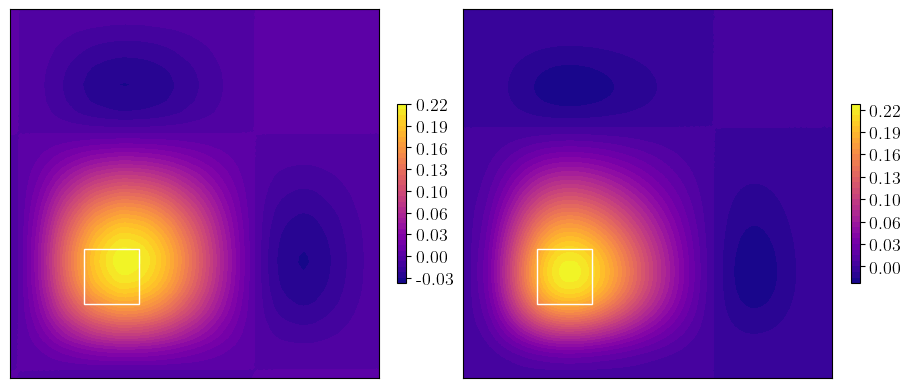

In [125]:
f_list = [as_func(x, pb['V_h']) for x in [x_cg, x_cg_restart]]
plot_multiple_f(f_list)

../../figures/number_of_iterations.png already exists


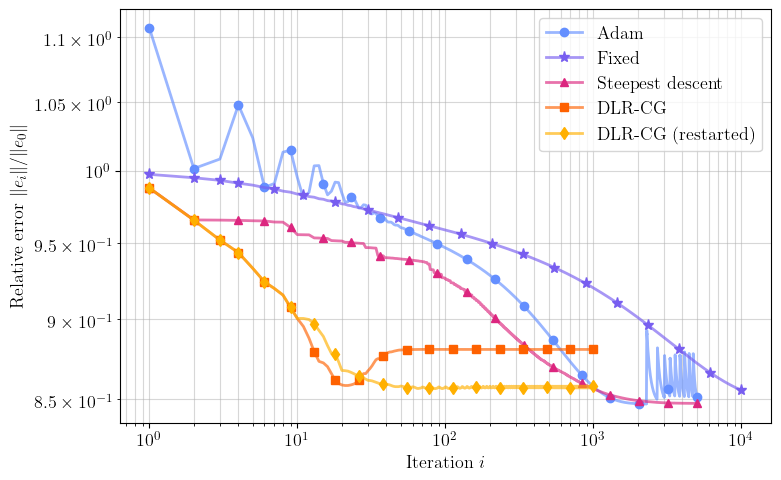

In [144]:
def plot_errors(e_list, names=None, fig_name=None):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    if names is None:
        names = ['' for _ in e_list]

    for i, e in enumerate(e_list):
        x = np.arange(1, len(e) + 1)

        # Makers with log-space position
        n_marks = 20
        x_marks = np.logspace(np.log10(x[0]), np.log10(x[-1]), n_marks)
        mark_idx = np.unique([np.abs(x - xm).argmin() for xm in x_marks])

        ax.loglog(x, e, lw=2.0, label=names[i], markevery=mark_idx, c=C5[i], alpha=.65)
        ax.loglog(x, e, M[i], lw=2.0, markevery=mark_idx, ms=MS[i], c=C5[i])


    # Custom labels
    handles, labels = [], names
    for i in range(len(e_list)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    ax.set_ylabel('Relative error $\| e_i \| / \| e_0 \|$')
    ax.set_xlabel('Iteration $i$')

    ax.grid(True, which='both', alpha=.5)
    ax.legend(handles=handles, labels=labels)
    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


e_list = [e_adam, e_fixed, e_sd, e_cg, e_cg_restart]
names = ['Adam', 'Fixed', 'Steepest descent', 'DLR-CG', 'DLR-CG (restarted)']
plot_errors(e_list, names=names, fig_name='number_of_iterations')

In [169]:
base_params = {'max_rank': 1, 'rtol': 1e-50, 'max_iter': 1_000, 'seed': SEED}

solver_cg = DynamicalLowRankCG(rsvd)
solver_cg.x_true = pb['x']

Nr_list = [5, 10, 20, None]
e_list = []
for restart in Nr_list:
    x_hat = solver_cg.solve(pb['y'], w, lam, restart_every=restart, **base_params)
    e_list.append(solver_cg.error.copy())

[##############################] 1000/1000
[##############################] 1000/1000
[##############################] 1000/1000
[##############################] 1000/1000


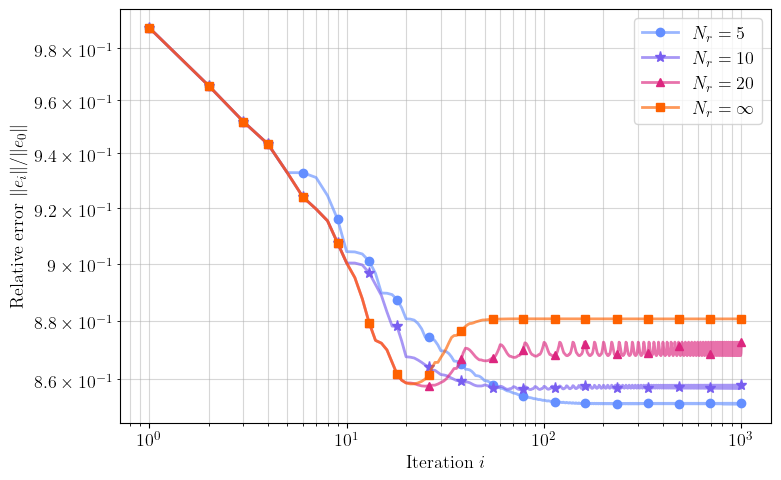

In [ ]:
# IMPORTANT NOTE: if N_r = 1, the algorithm is equivalent with "steepest descent" 
names = [f'$N_r = {N_r}$' for N_r in Nr_list]
names[-1] = '$N_r = \infty$'
plot_errors(e_list, names=names, fig_name=None)